In [2]:
import scanpy as sc
from pathlib import Path

In [3]:
INDIR = Path.home()/'project/crc-pm/result/latest.h5ad'
adata = sc.read_h5ad(INDIR)
adata_str = adata[adata.obs['Compartment'] == 'Stromal']
del adata

In [4]:
sc.pp.neighbors(
    adata_str,
    use_rep="X_scVI",
    n_neighbors=20,
    metric="cosine",
    random_state=42,
)

sc.tl.umap(
    adata_str,
    min_dist=0.25,
    random_state=2026,)

# use different res
leiden_res = [0.25, 0.5, 1.0]
for i in leiden_res:
    sc.tl.leiden(adata_str, key_added=f"leiden_res{i}", resolution=i, flavor="igraph", n_iterations=2)


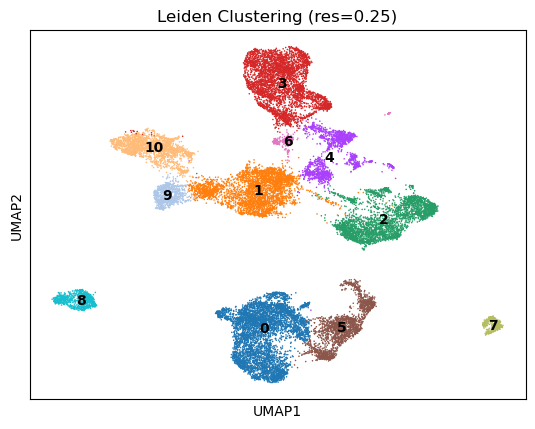

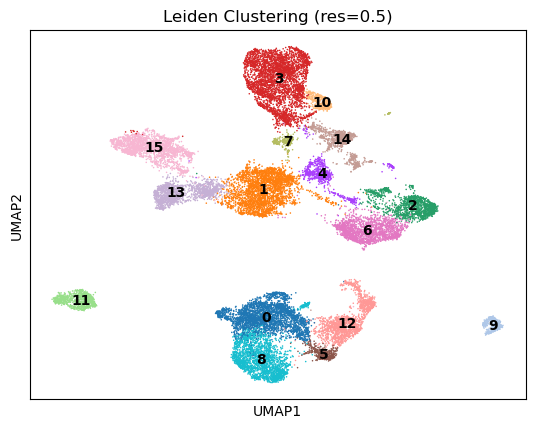

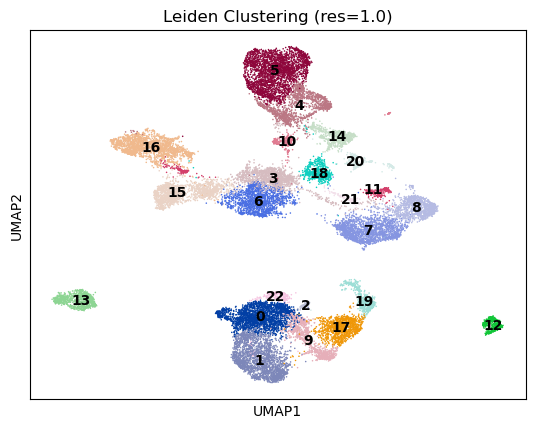

In [4]:
for i in leiden_res:
    sc.pl.umap(
        adata_str,
        color=f"leiden_res{i}",
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )

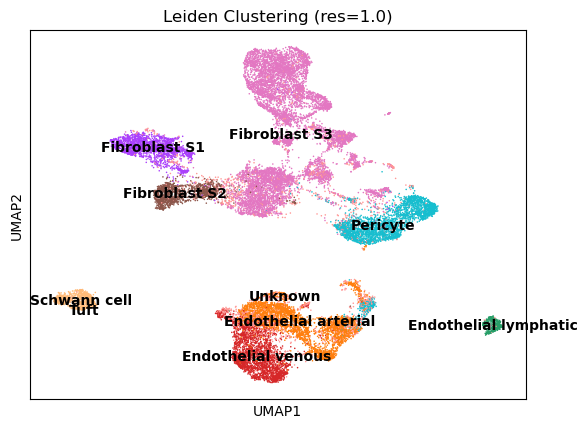

In [9]:
sc.pl.umap(
        adata_str[~adata_str.obs['scANVI_CellType'].isin(['Cancer Crypt-like','Plasma IgM','Macrophage'])],
        color='scANVI_CellType',
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )

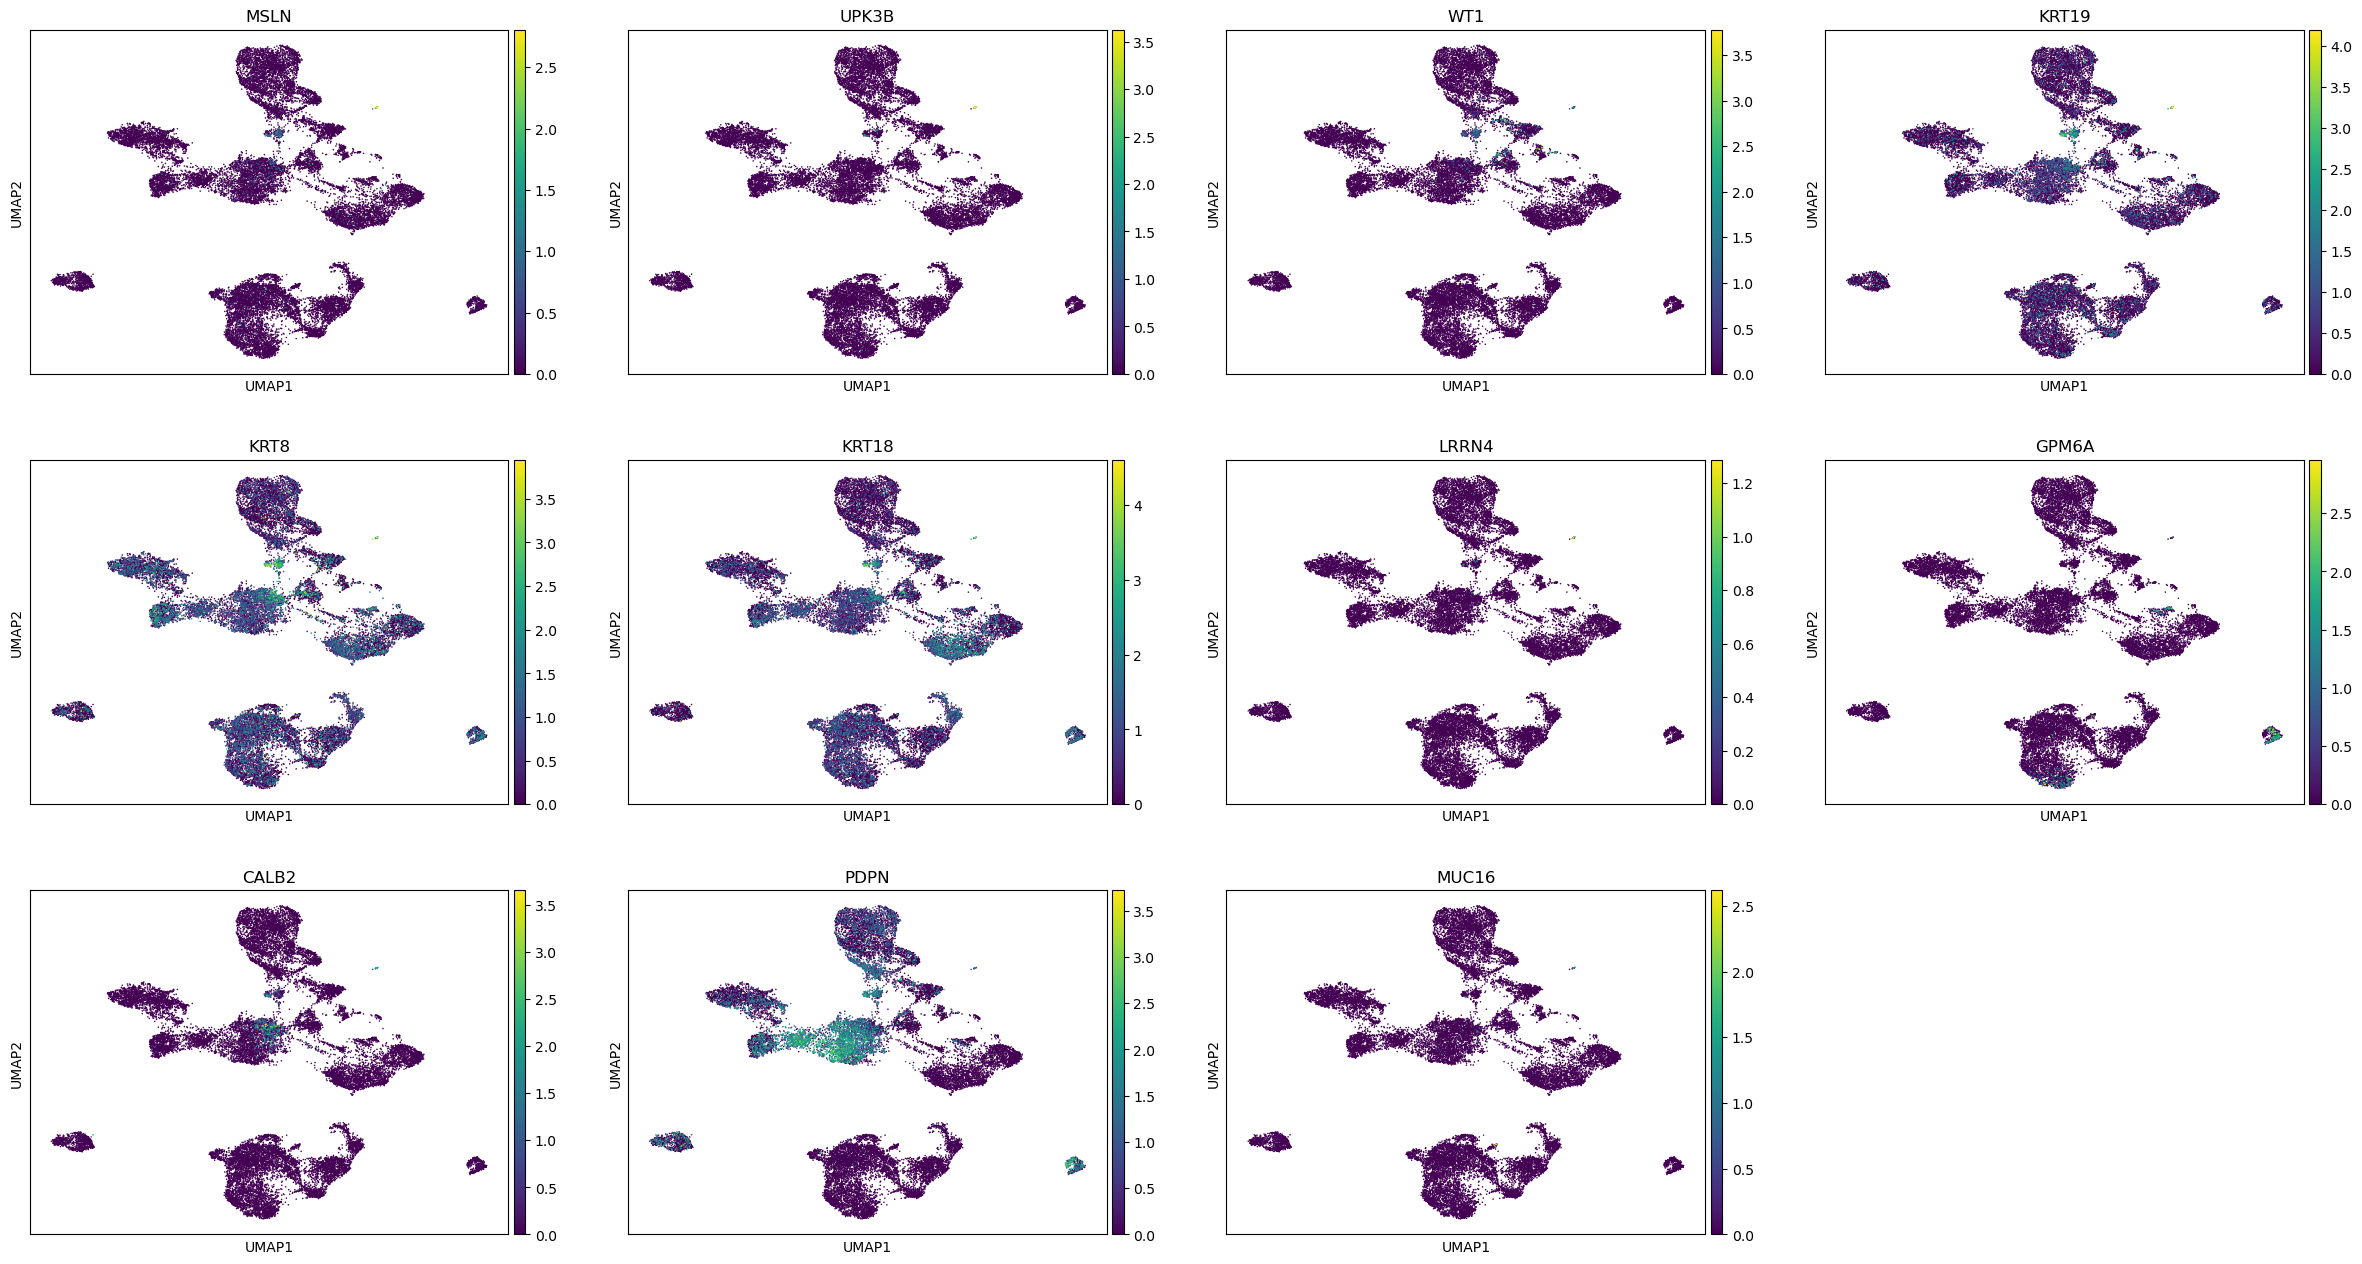

In [7]:
MESO_MARKERS = ['MSLN', 'UPK3B', 'WT1', 'KRT19', 'KRT8', 'KRT18', 'LRRN4', 'GPM6A', 'CALB2', 'PDPN', 'MUC16']
sc.pl.umap(
        adata_str[~adata_str.obs['scANVI_CellType'].isin(['Cancer Crypt-like','Plasma IgM','Macrophage'])],
        color=MESO_MARKERS,
        gene_symbols="gene_name",
        layer="log1p",
    )